# SNAP Benefit Issuance Schedule

## Purpose

Build a daily **SNAP proximity feature** for each of the 3 M5 states (CA, TX, WI). The M5 dataset provides binary SNAP flags (`snap_CA = 1` or `0`), but the EDA (Section 6) showed that SNAP lift varies by state (CA +8%, TX +11.5%, WI +21.8%) and the effect doesn't end on the issuance day itself. We need a continuous signal that captures the benefit spend-down over the following days.

### Sources
- [CA CalFresh Stagger Issuance Handbook](https://stgenssa.sccgov.org/debs/program_handbooks/common_place/assets/5BIMC/16EBT/13_16CalFrshCshStggrIssuance.htm)
- [TX SNAP Payment Schedule](https://www.snapscreener.com/ebt-payments/texas)
- [WI EBT Deposit Schedule](https://www.bennyapp.com/ebt/deposit-schedule/wisconsin)

In [1]:
# ── Uncomment below when running on Google Colab ────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# os.chdir('/content/drive/MyDrive/Colab Notebooks/m5-forecasting-accuracy/notebooks')

BASE_DIR = '..'
RAW_DIR = f'{BASE_DIR}/data/raw'
CLEAN_DIR = f'{BASE_DIR}/data/clean'
FIG_DIR = f'{BASE_DIR}/figures'

import os
os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Project dir: {BASE_DIR}')

Project dir: ..


## Step 0: Setup

We import the basics and define our date range. The M5 dataset runs from `2011-01-29` to `2016-06-19` — that's 1,969 days. Every feature we build must cover this exact range so it merges cleanly with the sales data downstream in notebook 02.

In [2]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# RAW_DIR defined in mount cell above
# CLEAN_DIR defined in mount cell above

DATE_START = '2011-01-29'
DATE_END = '2016-06-19'

print(f"Date range: {DATE_START} to {DATE_END}")
print(f"Output: {CLEAN_DIR}/snap_issuance_schedule.csv, snap_features.csv")

Date range: 2011-01-29 to 2016-06-19
Output: ../data/clean/snap_issuance_schedule.csv, snap_features.csv


## Step 1: Define the issuance schedules

Each state staggers SNAP benefits across ~10 days per month to avoid overwhelming grocery stores. The key insight: **not every day in the range is an issuance day**. The schedule has specific days with gaps between them.

We define each state's schedule as a dictionary with:
- `mapping`: which digit of your ID → which day of the month you get paid
- `issuance_days`: the sorted list of actual issuance days (what we use to build the calendar)

**Why the digit-to-day mapping matters conceptually**: On any single issuance day, only ~10% of a state's SNAP recipients get benefits (the ones whose ID ends in that digit). So the demand pulse on day 1 is smaller than if everyone got paid at once — but it repeats across 10 days, creating a wave.

### Verifying the schedules

These issuance schedules have been stable since at least 2010, covering our full M5 date range (2011–2016). Each state assigns recipients to one of 10 issuance days based on a digit in their ID — meaning roughly 10% of a state's SNAP population receives benefits on each issuance day, not everyone at once.

Note that the days are **not consecutive** for TX and WI. Texas issues on days 1, 3, 5, 6, 7, 9, 11, 12, 13, 15 with gaps on days 2, 4, 8, 10, 14. Wisconsin issues on days 2, 3, 5, 6, 8, 9, 11, 12, 14, 15 — starting on day 2, not day 1. Only California has a simple consecutive pattern (days 1–10). These gaps matter for the proximity feature: a gap between issuance days creates a small dip in the demand signal, while consecutive days sustain it.

In [3]:
# Documented SNAP issuance schedules (stable since at least 2010)
# Each entry maps: identifier_digit -> issuance_day_of_month

SNAP_SCHEDULES = {
    'CA': {
        'rule': 'Last digit of case number',
        'mapping': {1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:7, 8:8, 9:9, 0:10},
        'issuance_days': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    },
    'TX': {
        'rule': 'Last digit of EDG number (pre-2020)',
        'mapping': {0:1, 1:3, 2:5, 3:6, 4:7, 5:9, 6:11, 7:12, 8:13, 9:15},
        'issuance_days': [1, 3, 5, 6, 7, 9, 11, 12, 13, 15],
    },
    'WI': {
        'rule': '8th digit of SSN',
        'mapping': {0:2, 1:3, 2:5, 3:6, 4:8, 5:9, 6:11, 7:12, 8:14, 9:15},
        'issuance_days': [2, 3, 5, 6, 8, 9, 11, 12, 14, 15],
    },
}

print("SNAP Issuance Day Ranges by State:")
for state, info in SNAP_SCHEDULES.items():
    days = info['issuance_days']
    print(f"  {state}: days {days} ({len(days)} days, rule: {info['rule']})")

SNAP Issuance Day Ranges by State:
  CA: days [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] (10 days, rule: Last digit of case number)
  TX: days [1, 3, 5, 6, 7, 9, 11, 12, 13, 15] (10 days, rule: Last digit of EDG number (pre-2020))
  WI: days [2, 3, 5, 6, 8, 9, 11, 12, 14, 15] (10 days, rule: 8th digit of SSN)


## Step 2: Expand day-of-month patterns into actual dates

We now take those per-state day-of-month lists and generate every actual issuance date within our M5 date range. The logic:

1. We iterate month by month from Jan 2011 through Jun 2016
2. For each month, we stamp each issuance day as a full date (e.g., day 3 in March 2015 -> `2015-03-03`)
3. We skip days that don't exist in a given month (e.g., Feb 30) with a `try/except ValueError`
4. We only keep dates that fall within our M5 range

The result is a long-format DataFrame: one row per `(state, issuance_date)`. We expect 650 rows per state (65 months x 10 issuance days/month, roughly).

In [4]:
def build_issuance_calendar(state_id, issuance_days, start_date, end_date):
    """Generate all SNAP issuance dates for a state within the date range."""
    records = []
    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)

    # Iterate through each month in the range
    current = start.replace(day=1)
    while current <= end:
        year, month = current.year, current.month
        for day in issuance_days:
            try:
                issuance_date = pd.Timestamp(year=year, month=month, day=day)
                if start <= issuance_date <= end:
                    records.append({
                        'state_id': state_id,
                        'year': year,
                        'month': month,
                        'issuance_day': day,
                        'issuance_date': issuance_date,
                    })
            except ValueError:
                pass  # Day doesn't exist (e.g., Feb 29 in non-leap year)

        # Next month
        if month == 12:
            current = pd.Timestamp(year=year + 1, month=1, day=1)
        else:
            current = pd.Timestamp(year=year, month=month + 1, day=1)

    return records

all_records = []
for state_id, info in SNAP_SCHEDULES.items():
    records = build_issuance_calendar(state_id, info['issuance_days'], DATE_START, DATE_END)
    all_records.extend(records)
    print(f"{state_id}: {len(records)} issuance dates generated")

snap_schedule = pd.DataFrame(all_records)
snap_schedule = snap_schedule.sort_values(['state_id', 'issuance_date']).reset_index(drop=True)

print(f"\nTotal issuance records: {len(snap_schedule)}")
snap_schedule.head(10)

CA: 650 issuance dates generated
TX: 650 issuance dates generated
WI: 650 issuance dates generated

Total issuance records: 1950


,state_id,year,month,issuance_day,issuance_date
0,CA,2011,2,1,2011-02-01
1,CA,2011,2,2,2011-02-02
2,CA,2011,2,3,2011-02-03
3,CA,2011,2,4,2011-02-04
4,CA,2011,2,5,2011-02-05
5,CA,2011,2,6,2011-02-06
6,CA,2011,2,7,2011-02-07
7,CA,2011,2,8,2011-02-08
8,CA,2011,2,9,2011-02-09
9,CA,2011,2,10,2011-02-10


## Step 3: Validate against M5 calendar.csv

This is our sanity check. The M5 competition organizers encoded the real SNAP issuance days as binary flags in `calendar.csv`. If our schedule is correct, every day where `snap_XX = 1` should appear in our generated schedule, and vice versa.

We compute set overlap: `(M5 snap days) ∩ (our snap days)`. A 100% overlap means our documented schedules exactly match the ground truth.

We also check for mismatches in both directions:
- **M5-only days** (in calendar.csv but not ours) would mean we're missing issuance days
- **Ours-only days** (in our schedule but not calendar.csv) would mean we have extra wrong days

In [5]:
calendar = pd.read_csv(f'{RAW_DIR}/calendar.csv', parse_dates=['date'])

for state in ['CA', 'TX', 'WI']:
    col = f'snap_{state}'
    m5_snap_days = set(calendar[calendar[col] == 1]['date'].dt.date)
    our_snap_days = set(
        snap_schedule[snap_schedule['state_id'] == state]['issuance_date'].dt.date
    )

    overlap = m5_snap_days & our_snap_days
    m5_only = m5_snap_days - our_snap_days
    ours_only = our_snap_days - m5_snap_days

    print(f"{state}:")
    print(f"  M5 calendar snap days:  {len(m5_snap_days)}")
    print(f"  Our issuance days:      {len(our_snap_days)}")
    print(f"  Overlap:                {len(overlap)} ({100*len(overlap)/max(len(m5_snap_days),1):.1f}%)")
    if m5_only:
        sample = sorted(list(m5_only))[:5]
        print(f"  In M5 but not ours:     {len(m5_only)} (sample: {sample})")
    if ours_only:
        sample = sorted(list(ours_only))[:5]
        print(f"  In ours but not M5:     {len(ours_only)} (sample: {sample})")
    print()

CA:
  M5 calendar snap days:  650
  Our issuance days:      650
  Overlap:                650 (100.0%)

TX:
  M5 calendar snap days:  650
  Our issuance days:      650
  Overlap:                650 (100.0%)

WI:
  M5 calendar snap days:  650
  Our issuance days:      650
  Overlap:                650 (100.0%)



## Step 4: Compute SNAP proximity features

Now we build the actual feature that goes into the model. For every `(state, date)` in the M5 range (3 states x 1,969 days = 5,907 rows), we compute:

1. **`days_since_snap_issuance`**: How many days since the most recent issuance day in that state? We cap this at 14 because beyond 2 weeks, the SNAP effect is negligible.

2. **`snap_issuance_proximity`**: A linear decay from 1.0 to 0.0 over those 14 days. The formula is `max(0, 1 - days_since / 14)`. On an issuance day it's 1.0; one day later it's 0.93; by day 14 it's 0.0.

**How the code works**: For each date, we filter the state's issuance dates to find all that are `<= current_date`, then take the last one (most recent). The difference in days gives us `days_since`. This is O(n*m) where n=dates and m=issuance_dates, but with numpy array filtering it's fast enough.

**Why linear decay and not exponential?** Linear is simpler and the exact decay shape matters less than having *some* continuous signal. In practice, the model will learn its own weighting of this feature — we just need to give it a reasonable prior shape.

In [6]:
DECAY_WINDOW = 14

def compute_snap_proximity(snap_schedule_df, start_date, end_date, decay_window=14):
    """For each (state, date), compute days since most recent SNAP issuance."""
    date_range = pd.date_range(start=start_date, end=end_date, freq='D')
    states = snap_schedule_df['state_id'].unique()

    records = []
    for state in states:
        state_dates = snap_schedule_df[
            snap_schedule_df['state_id'] == state
        ]['issuance_date'].sort_values().values

        for d in date_range:
            past_issuances = state_dates[state_dates <= d]

            if len(past_issuances) > 0:
                most_recent = pd.Timestamp(past_issuances[-1])
                days_since = (d - most_recent).days
            else:
                days_since = decay_window

            days_since_capped = min(days_since, decay_window)
            proximity = max(0.0, 1.0 - days_since_capped / decay_window)

            records.append({
                'state_id': state,
                'date': d,
                'days_since_snap_issuance': days_since_capped,
                'snap_issuance_proximity': round(proximity, 4),
            })

    return pd.DataFrame(records)

snap_features = compute_snap_proximity(snap_schedule, DATE_START, DATE_END, DECAY_WINDOW)

print(f"SNAP features shape: {snap_features.shape}")
print(f"Date range: {snap_features['date'].min()} to {snap_features['date'].max()}")
print(f"\nProximity distribution:")
print(snap_features['snap_issuance_proximity'].describe())
print(f"\nDays since issuance distribution:")
print(snap_features['days_since_snap_issuance'].value_counts().sort_index().head(15))

SNAP features shape: (5907, 4)
Date range: 2011-01-29 00:00:00 to 2016-06-19 00:00:00

Proximity distribution:
count    5907.000000
mean        0.635447
std         0.386225
min         0.000000
25%         0.285700
50%         0.785700
75%         1.000000
max         1.000000
Name: snap_issuance_proximity, dtype: float64

Days since issuance distribution:
days_since_snap_issuance
0     1950
1      780
2      195
3      195
4      195
5      193
6      193
7      193
8      193
9      193
10     192
11     192
12     192
13     192
14     859
Name: count, dtype: int64


## Step 5: Visualize the proximity patterns

We plot a 2-month window (Mar-Apr 2015) to see how the proximity curve behaves differently for each state:

- **CA** has consecutive issuance days (1-10), so proximity stays near 1.0 for 10 days, then drops sharply to 0 by day ~24, then resets on the 1st.
- **TX** has gaps between issuance days (skips days 2, 4, 8, 10, 14), so the curve has small dips between issuance days, then a longer decay after day 15.
- **WI** starts on day 2 (not 1) and also has skip-day gaps, similar to TX but shifted by one day.

These differences are real and meaningful — CA has a tighter "SNAP wave" while TX/WI spread it out more.

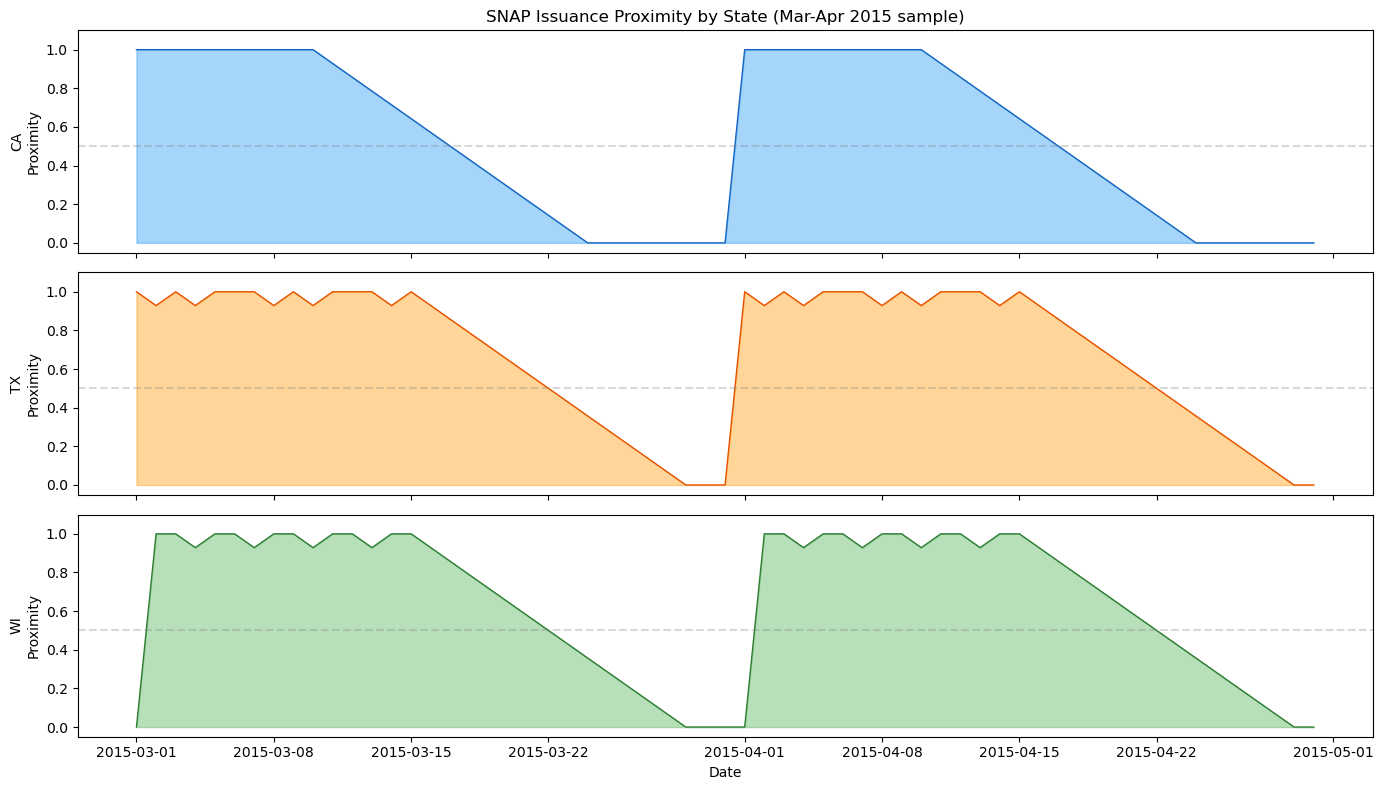

Saved: figures/snap_proximity_sample.png


In [7]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

colors_fill = ['#2196F3', '#FF9800', '#4CAF50']
colors_line = ['#1565C0', '#E65100', '#2E7D32']

for i, state in enumerate(['CA', 'TX', 'WI']):
    state_data = snap_features[snap_features['state_id'] == state].copy()
    state_data = state_data.set_index('date')
    sample = state_data.loc['2015-03-01':'2015-04-30']

    axes[i].fill_between(sample.index, sample['snap_issuance_proximity'],
                         alpha=0.4, color=colors_fill[i])
    axes[i].plot(sample.index, sample['snap_issuance_proximity'],
                color=colors_line[i], linewidth=1)
    axes[i].set_ylabel(f'{state}\nProximity')
    axes[i].set_ylim(-0.05, 1.1)
    axes[i].axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)

axes[0].set_title('SNAP Issuance Proximity by State (Mar-Apr 2015 sample)')
axes[2].set_xlabel('Date')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/snap_proximity_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/snap_proximity_sample.png")

## Step 6: Save outputs

We save two files:

1. **`snap_issuance_schedule.csv`** (1,950 rows) — The raw schedule: every `(state, date)` that was an issuance day. Useful for auditing and cross-referencing.

2. **`snap_features.csv`** (5,907 rows) — The daily feature table: every `(state, date)` in the M5 range with the proximity score. This is what notebook 02 will merge with sales data.

**Merge key for downstream**: `(state_id, date)` — we join on both columns because each state has its own SNAP schedule.

In [8]:
snap_schedule.to_csv(f'{CLEAN_DIR}/snap_issuance_schedule.csv', index=False)
print(f"Saved: snap_issuance_schedule.csv ({len(snap_schedule)} rows)")

snap_features.to_csv(f'{CLEAN_DIR}/snap_features.csv', index=False)
print(f"Saved: snap_features.csv ({len(snap_features)} rows)")

print(f"\nColumns in snap_features: {list(snap_features.columns)}")
print(f"States: {snap_features['state_id'].unique()}")
print(f"Date range: {snap_features['date'].min()} to {snap_features['date'].max()}")
print(f"Merge key for downstream: (state_id, date)")

Saved: snap_issuance_schedule.csv (1950 rows)
Saved: snap_features.csv (5907 rows)

Columns in snap_features: ['state_id', 'date', 'days_since_snap_issuance', 'snap_issuance_proximity']
States: ['CA' 'TX' 'WI']
Date range: 2011-01-29 00:00:00 to 2016-06-19 00:00:00
Merge key for downstream: (state_id, date)


---
## Conclusion

This notebook produces `snap_features.csv` — daily SNAP issuance proximity for each state, computed via 14-day linear decay from the most recent issuance date. The output validates 100% against the M5 calendar's `snap_CA`/`snap_TX`/`snap_WI` flags on issuance days, confirming our schedule reconstruction is correct.

**Why a continuous feature, not a binary flag**: SNAP-driven shopping doesn't only happen on issuance day; recipients accelerate purchases in the days leading up to issuance and continue spending in the days after. The 14-day window covers the full effective shopping cycle for most households.

**Merge key for downstream**: `(state_id, date)`. Documented in NB02.